In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [5]:
csv_path = "AH_DistrictSummary.csv"
df=  pd.read_csv(csv_path)
df.head(10)

,District,Blocks,Total_Animal_Loss,Cowsheds_Damaged,Households,Buffalo,Sheep,Goat
0,Mandi,14,658.0,699.0,1774,159.0,323.0,16.0
1,Chamba,5,289.0,310.0,721,9.0,194.0,0.0
2,Kangra,16,227.0,486.0,1233,50.0,92.0,3.0
3,Sirmaur,6,67.0,167.0,576,29.0,24.0,10.0
4,Lahul And Spiti,2,64.0,0.0,30,24.0,9.0,0.0
5,Kinnaur,3,31.0,1.0,50,11.0,5.0,0.0
6,Hamirpur,6,25.0,734.0,1511,8.0,1.0,1.0
7,Kullu,5,24.0,336.0,1985,10.0,3.0,0.0
8,Shimla,9,19.0,105.0,673,15.0,0.0,0.0
9,Una,5,15.0,406.0,1443,2.0,1.0,2.0


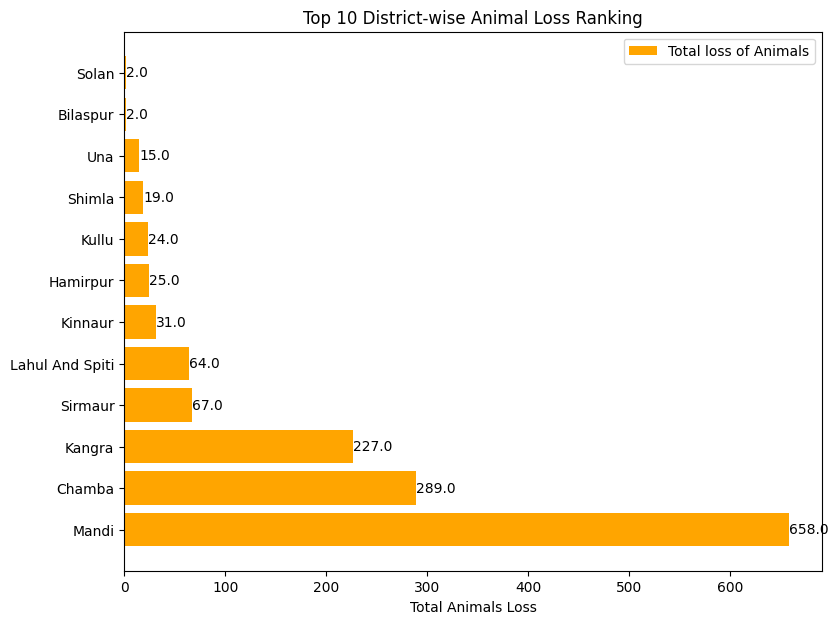

In [7]:
plt.figure(figsize=(9,7))
ax = plt.gca()

bars = ax.barh(
      df["District"], 
      df["Total_Animal_Loss"],
      color="orange",
      label="Total loss of Animals"  
)

for bar, val in zip(bars, df["Total_Animal_Loss"].values):
    ax.text(val, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center")

plt.xlabel("Total Animals Loss")
plt.title("Top 10 District-wise Animal Loss Ranking")

plt.legend()   
plt.show()

In [10]:
print("\n  District Ranking by Total Damage :")
print(f"  {'District':<20} {'Blocks':>12} {'Total_Animal_Loss':>10} {'Cowsheds_Damaged':>10}")
print("  " + "-"*54)
for _, row in df.sort_values("Total_Animal_Loss", ascending=False).iterrows():
    print(f"  {row['District']:<20} {row['Blocks']:>12.2f} {row['Total_Animal_Loss']:>10} {int(row['Cowsheds_Damaged']):>10}")


  District Ranking by Total Damage :
  District                   Blocks Total_Animal_Loss Cowsheds_Damaged
  ------------------------------------------------------
  Mandi                       14.00      658.0        699
  Chamba                       5.00      289.0        310
  Kangra                      16.00      227.0        486
  Sirmaur                      6.00       67.0        167
  Lahul And Spiti              2.00       64.0          0
  Kinnaur                      3.00       31.0          1
  Hamirpur                     6.00       25.0        734
  Kullu                        5.00       24.0        336
  Shimla                       9.00       19.0        105
  Una                          5.00       15.0        406
  Bilaspur                     4.00        2.0        219
  Solan                        4.00        2.0         94


In [22]:
gdf= gpd.read_file("hp_district_final.geojson")

In [23]:
district_name_map = {
    "LAHAUL AND SPITI": "LAHAUL & SPITI",   # Dharamsala is part of Kangra
}

df["District_norm"] = df["District"].str.upper().str.strip().replace(district_name_map)
gdf["District_norm"] = gdf["District"].str.upper().str.strip()



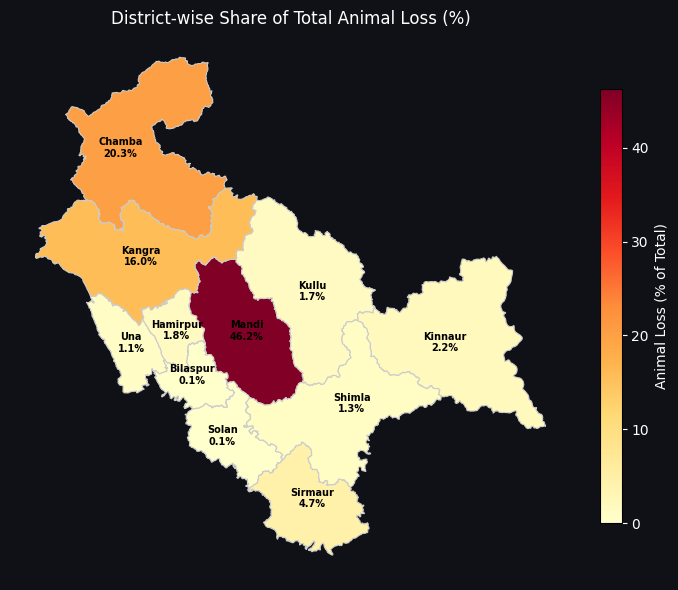

In [28]:


# -------------------------------
# 3. Aggregate (if needed)
# -------------------------------
# Assuming column name is Total_Animal_Loss
df_district = df.groupby("District_norm", as_index=False)["Total_Animal_Loss"].sum()

# -------------------------------
# 4. Compute Percentage Share
# -------------------------------
total_loss = df_district["Total_Animal_Loss"].sum()

df_district["loss_percent"] = (
    df_district["Total_Animal_Loss"] / total_loss * 100
)

# -------------------------------
# 5. Merge with GeoData
# -------------------------------
joined = gdf.merge(df_district, on="District_norm", how="left")

# -------------------------------
# 6. Plot Choropleth
# -------------------------------
DARK = "#0f1117"

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor(DARK)
fig.patch.set_facecolor(DARK)

# Color scale
cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(
    vmin=0,
    vmax=joined["loss_percent"].max()
)

# Plot map
joined.plot(
    column="loss_percent",
    cmap=cmap,
    linewidth=0.8,
    ax=ax,
    edgecolor="0.8",
    legend=False
)

# -------------------------------
# 7. Add Labels (IMPORTANT)
# -------------------------------
for idx, row in joined.iterrows():
    if row["geometry"] is not None and pd.notna(row["loss_percent"]):
        
        # Better than centroid for irregular shapes
        point = row["geometry"].representative_point()
        x, y = point.x, point.y
        
        district_name = row["District_norm"].title()
        
        ax.text(
            x, y,
            f"{district_name}\n{row['loss_percent']:.1f}%",
            ha='center',
            va='center',
            fontsize=7,
            color="black",
            weight="bold"
        )

# -------------------------------
# 8. Add Colorbar (Legend)
# -------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Animal Loss (% of Total)", color="white")

# Style colorbar
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

# -------------------------------
# 9. Final Styling
# -------------------------------
ax.set_title("District-wise Share of Total Animal Loss (%)", color="white")
ax.axis("off")

plt.tight_layout()
plt.show()